# Lime perturbations

```python
fudge_config = {
    # same, same_shape, flat, with_mean, gaussians, scale
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": 0.9,
    # flat
    "continuum": 1,
    # gaussians
    "amplitude": 1.0,
    "sigmas_in_segment": 8,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}
```

In [1]:
import os
# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

## Relevant libraries

In [2]:
import pickle

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker

import matplotlib.image as mpimg
import numpy as np
import pandas as pd

from anomaly.constants import GALAXY_LINES
from anomaly.utils import specobjid_to_idx
from astroExplain.spectra.notebook import explain_reconstruction_score
from astroExplain.spectra.explanation import TellMeWhy
from astroExplain.spectra import clustering

from autoencoders.ae import AutoEncoder
from sdss.metadata import MetaData
from sdss.utils.managefiles import FileDirectory

meta = MetaData()

# Custom functions

## N segments

In [3]:
def compute_n_segments(n_wavelengths, n_segments):
    """Compute the segments based on the number of wavelengths and segments."""
    base_size, residual_size = divmod(n_wavelengths, n_segments)
    if residual_size > 0:
        n_segments += 1

    print(f"Base size: {base_size}, Residual size: {residual_size}")
    print(f"New number of segments: {n_segments}")


## Weights unit normalization

In [4]:
def unit_norm_weights(
    wave, spectrum,
    score_config,
    lime_config,
    fudge_config,
    ae_model
)-> np.ndarray:
    (
        explanation,
        ret_exp_score,
        ret_exp_local_pred
    ) = explain_reconstruction_score(
        wave=wave, spectrum=spectrum,
        score_config=score_config,
        lime_config=lime_config,
        fudge_config=fudge_config,
        model=ae_model
    )

    why = TellMeWhy(wave=wave, explanation=explanation)

    weights = why.get_heatmap()
    nan_mask = np.isnan(weights)
    weights[nan_mask] = 0
    weights = weights.reshape(1, -1)

    weights = clustering.normalize_weights_l2_abs(weights)
    weights = weights.reshape(-1)
    return weights, why


## Plot explanations

In [5]:
def plot_explanation(
    weights: np.ndarray,
    why: TellMeWhy,
    max_norm_weights: bool = False,
    figure_size=None,
):

    fig, axs = why.plot_full_explanation(figure_size=figure_size)

    axs[0].plot(why.wave, why.galaxy, c="black")
    axs[0].set_ylabel("Normalized flux")

    max_weight = np.nanmax(weights)

    if max_norm_weights:
        weights /= max_weight

    axs[1].plot(
        why.wave, weights, color="black"
    )
    axs[1].set_ylabel("Explanation weights")
    axs[1].set_xlabel(r"$\lambda$ [nm]")
    
    return fig, axs


## Explain 3 rows

In [16]:
def explain_three_rows_fudge(
    wave: np.ndarray, spectrum: np.ndarray,
    perturbed_param:str,
    fudge_config: dict,
    fudge_factors:list,
    score_config: dict,
    lime_config: dict,
    model: AutoEncoder,
):

    weights_perturbations = []
    whys_perturbations = []

    for factor in fudge_factors:

        fudge_config[perturbed_param] = factor

        weights, why = unit_norm_weights(
            wave, spectrum,
            score_config,
            lime_config,
            fudge_config,
            model
        )

        weights_perturbations.append(weights)
        whys_perturbations.append(why)

    return weights_perturbations, whys_perturbations

## Plot 3 rows

In [34]:
def plot_three_rows_fudge(
    wave: np.ndarray,
    spectrum: np.ndarray,
    weights_perturbations,
    fudge_labels: list,
    x_factor: float,
    y_factor: float,
    figsize=(7, 3.5)
):

    fig, axs = plt.subplots(
        nrows=1 + len(fudge_labels),
        ncols=1,
        sharex=True,
        figsize=figsize
    )


    axs[0].plot(wave, spectrum, c="black")
    axs[0].set_xlim(350, 770)
    wave_ticks = list(np.arange(400, 751, 50))
    axs[0].set_xticks(wave_ticks)

    for idx, weights in enumerate(weights_perturbations):

        axs[idx + 1].plot(
            wave,
            weights,
            color="black",
            label=fudge_labels[idx],
        )

    axs[-1].set_xlabel(r"$\lambda$ [nm]")

    for idx, factor in enumerate(fudge_labels):
        axs[idx + 1].text(
            x_factor,
            y_factor,
            factor,
            horizontalalignment="center",
            verticalalignment="center",
            transform=axs[idx + 1].transAxes,
            # fontsize="small",
    )

    return fig, axs

# Data ingestion

In [7]:
phd_dir = "/home/elom/phd/00_phd_code"
data_dir = f"{phd_dir}/spectra"
model_dir = f"{phd_dir}/models"
bin_id = "bin_03"
params_dir = f"{phd_dir}/lime_params/{bin_id}"
paper_figs_dir = "/home/elom/phd/00_paper_explain-me-why/sections/figures"
submission_dir = "/home/elom/phd/00_paper_explain-me-why/submission"

In [8]:
meta_data_df = pd.read_csv(
    f"{data_dir}/drop_0_01_z_0_5_4_0_snr_inf.csv.gz",
    index_col="specobjid",
)

In [10]:
wave = np.load(f"{data_dir}/wave_spectra_imputed.npy")
# convert Angstroms to nanometers
wave = wave / 10.0
spectra = np.load(
    f"{data_dir}/spectra_imputed.npy",
    mmap_mode="r"
)

idx_id = np.load(
    f"{data_dir}/{bin_id}/{bin_id}_index_specobjid.npy"
)

In [11]:
spectra.shape, idx_id.shape

((728133, 3773), (181850, 2))

## Load model

In [12]:
ae_model = AutoEncoder(
    reload=True,
    reload_from=f"{model_dir}/{bin_id}",
)

# Baseline explanation: broad_near_halpha

Set explainer and Get explanations
http://skyserver.sdss.org/dr16/en/tools/explore/summary.aspx?sid=2664004586678806528&apid=


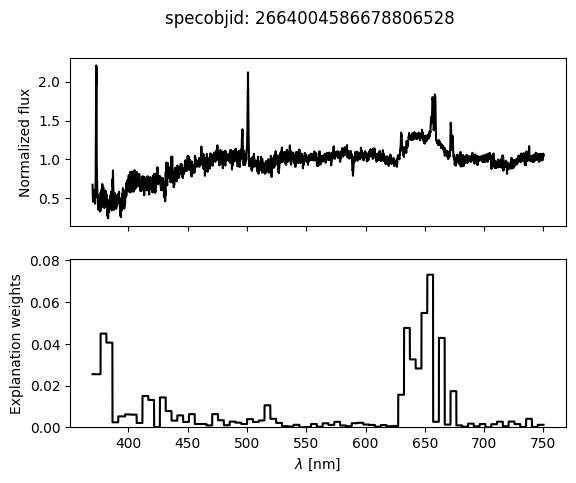

In [13]:
broad_near_halpha_id = 2664004586678806528
idx_spectrum = specobjid_to_idx(broad_near_halpha_id, idx_id)
spec_broad_near_halpha = spectra[idx_spectrum]

base_line_score_config = {
    "metric": "mse",
    "velocity": 250,
    # if reconstruction
    "relative": False,
    "percentage": 97,
    "epsilon": 0.001,
    "lines": list(GALAXY_LINES.keys()),
}

base_line_metric_str = "mse_filter_250kms_noRel97"

base_line_lime_config = {
    "segmentation": "uniform",
    "number_segments": 77,
    "number_samples": 5000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10000,
}

baseline_fudge_config = {
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": 0.9,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}

weights, why = unit_norm_weights(
    wave, spec_broad_near_halpha,
    base_line_score_config,
    base_line_lime_config,
    baseline_fudge_config,
    ae_model
)


fig, axs = plot_explanation(
    weights=weights,
    why=why,
)

max_weight = np.nanmax(weights)
axs[1].set_ylim(0, 1.1*max_weight)

fig.suptitle(f"specobjid: {broad_near_halpha_id}")

print(meta.get_sky_server_url(broad_near_halpha_id))

# Scale fudge

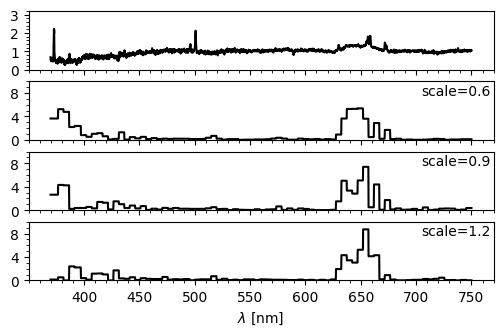

In [49]:
fudge_scale_config = {
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": None,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}

scale_factors = [0.6, 0.9, 1.2]

# weights_perturbations, whys_perturbations = explain_three_rows_fudge(
#     wave, spec_broad_near_halpha,
#     perturbed_param="scale_factor",
#     fudge_config=fudge_scale_config,
#     fudge_factors=scale_factors,
#     score_config=base_line_score_config,
#     lime_config= base_line_lime_config,
#     model=ae_model,
# )

fig, axs = plot_three_rows_fudge(
    weights_perturbations=weights_perturbations,
    wave=wave,
    spectrum=spec_broad_near_halpha,
    fudge_labels=[f"scale={factor}" for factor in scale_factors],
    x_factor=0.92,
    y_factor=0.84,
    figsize=(6, 3.5)
)

axs[0].set_ylim(0, 3.2)
w_ticks = [0, 1, 2, 3]
axs[0].set_yticks(w_ticks)

# max_weight = 1.1*np.nanmax(weights_perturbations)
for ax in axs[1:]:

    ax.set_ylim(0, 0.1)

    w_ticks = [0, 0.04, 0.08]
    ax.set_yticks(w_ticks)

    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{int(x * 100)}")
    )
    ax.set_ylabel("")


for ax in axs.flatten(): ax.minorticks_on()

# adjust vertical space
# plt.subplots_adjust(
#     hspace=0.1,
# )


segmentation = base_line_lime_config["segmentation"]
n_segments = base_line_lime_config["number_segments"]
explanation_str = (
    f"{segmentation}_{n_segments}_{base_line_metric_str}"
)
fig_name = (
    f"scale_factors_{explanation_str}_"
    f"specobjid_{broad_near_halpha_id}"
)
fig.savefig(
    f"{params_dir}/{fig_name}.pdf",
    bbox_inches="tight"
)
fig.savefig(
    f"{params_dir}/{fig_name}.jpeg",
    bbox_inches="tight"
)

fig.savefig(
    f"{paper_figs_dir}/perturbation/{fig_name}.pdf",
    bbox_inches="tight"
)
fig.savefig(
    f"{paper_figs_dir}/perturbation/jpeg/{fig_name}.jpeg",
    bbox_inches="tight"
)
fig.savefig(
    f"{submission_dir}/{fig_name}.pdf",
    bbox_inches="tight"
)

# Flat fudge

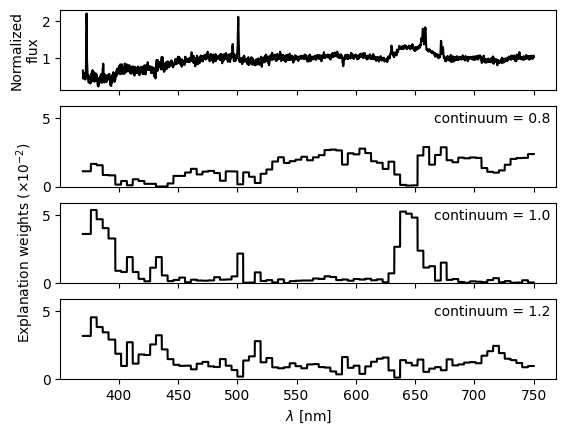

In [98]:
fudge_flat_config = {
    # same, same_shape, flat, with_mean, gaussians, scale
    "kind_of_fudge": "flat",
    # flat
    "continuum": None,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}

flat_factors = [0.8, 1.0, 1.2]
# weights_perturbations, whys_perturbations = explain_three_rows_fudge(
#     wave, spec_broad_near_halpha,
#     perturbed_param="continuum",
#     fudge_config=fudge_flat_config,
#     fudge_factors=flat_factors,
#     score_config=base_line_score_config,
#     lime_config= base_line_lime_config,
#     model=ae_model,
# )

font_size = None
flat_labels = [f"continuum = {factor}" for factor in flat_factors]

fig, axs = plot_three_rows_fudge(
    weights_perturbations=weights_perturbations,
    whys_perturbations=whys_perturbations,
    wave=wave,
    font_size=font_size,
    spectrum=spec_broad_near_halpha,
    fudge_factors=flat_factors,
    fudge_labels=flat_labels,
    x_factor=0.87,
    y_factor=0.84,
)

max_weight = 1.1*np.nanmax(weights_perturbations)
for ax in axs[1:]:
    ax.set_ylim(0, max_weight)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{int(x * 100)}")
    )
    ax.set_ylabel("")

# Compute center of bottom three axes
bottom_y = axs[3].get_position().y0
top_y = axs[1].get_position().y1
center_y = (bottom_y + top_y) / 2

# Add vertical label
font_size = None
x_vertical = 0.07
fig.text(
    x_vertical, center_y,
    "Explanation weights ($\\times 10^{-2}$)",
    va='center', ha='center',
    rotation='vertical', fontsize=font_size
)

bbox = axs[0].get_position()
center_y_flux = (bbox.y0 + bbox.y1) / 2

fig.text(
    x_vertical, center_y_flux,
    "Normalized\nflux",
    va='center', ha='center',
    rotation='vertical', fontsize=font_size
)

segmentation = base_line_lime_config["segmentation"]
n_segments = base_line_lime_config["number_segments"]
explanation_str = f"{segmentation}_{n_segments}_{base_line_metric_str}"
fig_name = (
    f"continuum_factors_{explanation_str}_"
    f"specobjid_{broad_near_halpha_id}"
)
fig_name

fig.savefig(f"{params_dir}/{fig_name}.pdf", bbox_inches="tight")
fig.savefig(f"{params_dir}/{fig_name}.jpeg", bbox_inches="tight")

fig.savefig(f"{paper_figs_dir}/perturbation/{fig_name}.pdf", bbox_inches="tight")
fig.savefig(f"{paper_figs_dir}/perturbation/jpeg/{fig_name}.jpeg", bbox_inches="tight")


# Mean perturbation

Set explainer and Get explanations


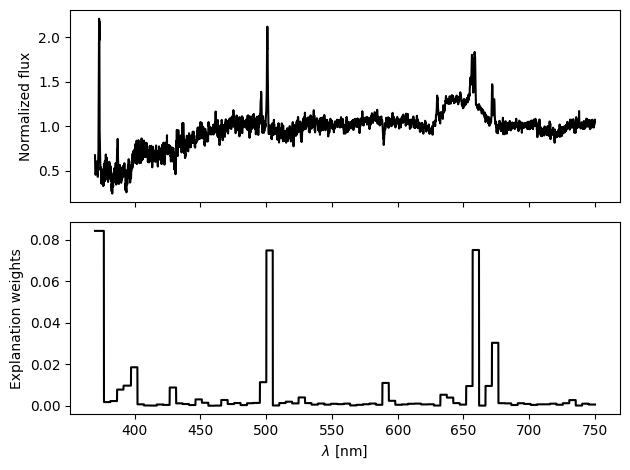

In [ ]:
fudge_mean_config = {
    "kind_of_fudge": "with_mean",
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}

weights, why = unit_norm_weights(
    wave, spec_broad_near_halpha,
    base_line_score_config,
    base_line_lime_config,
    fudge_mean_config,
    ae_model
)

fig, axs = plot_explanation(
    weights=weights,
    why=why,
)

# fig.suptitle(f"Explanation with mean flux per segment")

segmentation = base_line_lime_config["segmentation"]
n_segments = base_line_lime_config["number_segments"]
explanation_str = f"{segmentation}_{n_segments}_{base_line_metric_str}"
fig_name = f"with_mean_{explanation_str}_specobjid_{broad_near_halpha_id}"
fig_name

plt.tight_layout()
fig.savefig(f"{params_dir}/{fig_name}.pdf", bbox_inches="tight")
fig.savefig(f"{params_dir}/{fig_name}.jpeg", bbox_inches="tight")

fig.savefig(f"{paper_figs_dir}/perturbation/{fig_name}.pdf", bbox_inches="tight")
fig.savefig(f"{paper_figs_dir}/perturbation/jpeg/{fig_name}.jpeg", bbox_inches="tight")


# Others with mean

## Strong emission lines

Set explainer and Get explanations


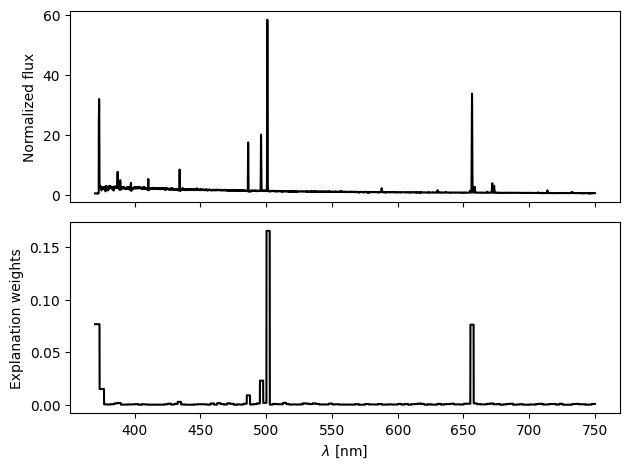

In [103]:
strong_emission_dict = {
    'specobjid': 3240467000396376064,
    'metric': 'mse_noRel100',
    'explanation': 'uniform_64_scale_0.9',
}

specobjid = strong_emission_dict["specobjid"]
idx_spectrum = specobjid_to_idx(specobjid, idx_id)
spec_strong_emission = spectra[idx_spectrum]
# ###########################################################33
# config file
strong_emission_score_config = {
    "metric": "mse",
    "velocity": 0,
    # if reconstruction
    "relative": False,
    "percentage": 100,
    "epsilon": 0.001,
    "lines": list(GALAXY_LINES.keys()),
}

strong_emission_lime_config = {
    "segmentation": "uniform",
    "number_segments": 150,
    "number_samples": 5000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10000,
}

fudge_with_mean_strong_emission_config = {
    "kind_of_fudge": "with_mean",
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}

weights, why = unit_norm_weights(
    wave, spec_strong_emission,
    strong_emission_score_config,
    strong_emission_lime_config,
    fudge_with_mean_strong_emission_config,
    ae_model
)

fig, axs = plot_explanation(
    weights=weights,
    why=why,
)

# fig.suptitle(f"specobjid: {specobjid}")

metric = strong_emission_dict["metric"]
segmentation = strong_emission_lime_config["segmentation"]
n_segments = strong_emission_lime_config["number_segments"]
explanation_str = f"{segmentation}_{n_segments}_{metric}"
fig_name = f"with_mean_strong_emission_{explanation_str}_specobjid_{specobjid}"
fig_name
plt.tight_layout()
fig.savefig(f"{params_dir}/{fig_name}.pdf", bbox_inches="tight")
fig.savefig(f"{params_dir}/{fig_name}.jpeg", bbox_inches="tight")

fig.savefig(f"{paper_figs_dir}/perturbation/{fig_name}.pdf", bbox_inches="tight")
fig.savefig(f"{paper_figs_dir}/perturbation/jpeg/{fig_name}.jpeg", bbox_inches="tight")

# print(meta.get_sky_server_url(specobjid))

## Artifact

Set explainer and Get explanations


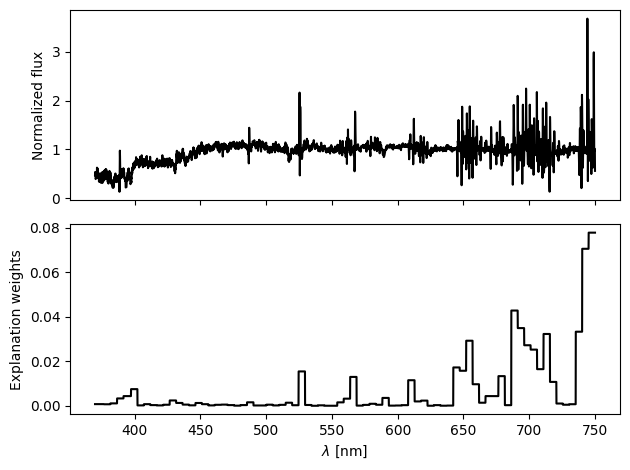

In [104]:
artifact_dict = {
    'specobjid': 637325355518027776,
    'metric': 'mse_noRel100',
    'explanation': 'uniform_64_scale_0.9',
}
specobjid = artifact_dict["specobjid"]
idx_spectrum = specobjid_to_idx(specobjid, idx_id)
spec_artifact = spectra[idx_spectrum]
# ###########################################################33
# config file
artifact_score_config = {
    "metric": "mse",
    "velocity": 0,
    # if reconstruction
    "relative": False,
    "percentage": 100,
    "epsilon": 0.001,
    "lines": list(GALAXY_LINES.keys()),
}

artifact_lime_config = {
    "segmentation": "uniform",
    "number_segments": 77,
    "number_samples": 5000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10000,
}

fudge_with_mean_artifact_config = {
    "kind_of_fudge": "with_mean",
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}

weights, why = unit_norm_weights(
    wave, spec_artifact,
    artifact_score_config,
    artifact_lime_config,
    fudge_with_mean_artifact_config,
    ae_model
)

fig, axs = plot_explanation(
    weights=weights,
    why=why,
)

# fig.suptitle(f"Explanation with mean flux per segment")
# fig.suptitle(f"specobjid: {specobjid}")

metric = artifact_dict["metric"]
segmentation = artifact_lime_config["segmentation"]
n_segments = artifact_lime_config["number_segments"]
explanation_str = f"{segmentation}_{n_segments}_{metric}"
fig_name = f"with_mean_artifact_{explanation_str}_specobjid_{specobjid}"
fig_name
plt.tight_layout()
fig.savefig(f"{params_dir}/{fig_name}.pdf")
fig.savefig(f"{params_dir}/{fig_name}.jpeg")
fig.savefig(f"{paper_figs_dir}/perturbation/{fig_name}.pdf")
fig.savefig(f"{paper_figs_dir}/perturbation/jpeg/{fig_name}.jpeg")
# print(meta.get_sky_server_url(specobjid))


# Segmentation

In [20]:
n_segments = 942
n_wavelengths = wave.shape[0]

compute_n_segments(n_wavelengths, n_segments)

Base size: 4, Residual size: 5
New number of segments: 943


**N wavelengths: 3773**
```python
Base size: 343, Residual size: 0
New number of segments: 11
# 
Base size: 34, Residual size: 33
New number of segments: 111
# 
Base size: 4, Residual size: 5
New number of segments: 943
```

## Uniform

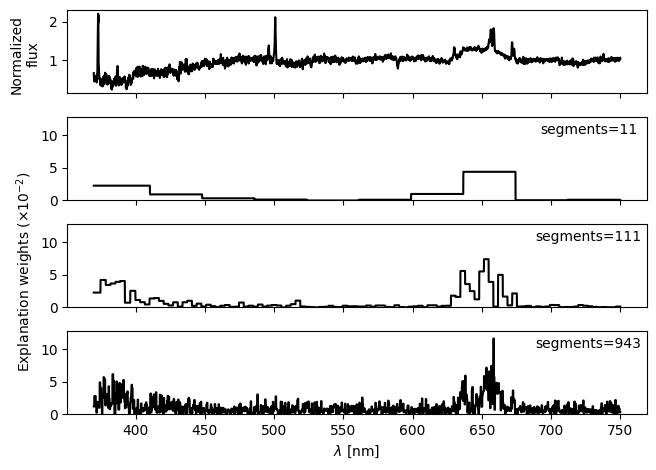

In [123]:
segments_lime_config = {
    "segmentation": "uniform",
    "number_segments": None,
    "number_samples": 5000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10000,
}


broad_near_halpha_id = 2664004586678806528
idx_spectrum = specobjid_to_idx(broad_near_halpha_id, idx_id)
spec_broad_near_halpha = spectra[idx_spectrum]


# weights_perturbations = []
# whys_perturbations = []

# n_segments = [10, 110, 942]

# for n in n_segments:

#     segments_lime_config["number_segments"] = n

#     weights, why = unit_norm_weights(
#         wave, spec_broad_near_halpha,
#         base_line_score_config,
#         segments_lime_config,
#         baseline_fudge_config,
#         ae_model
#     )

#     weights_perturbations.append(weights)
#     whys_perturbations.append(why)
##############################################################
# Generate perturbation figures
n_segments = [11, 111, 943]

n_segments_labels = [f"segments={n}" for n in n_segments]

fig, axs = plt.subplots(
    nrows=1 + len(n_segments),
    ncols=1,
    sharex=True,
)

axs[0].plot(wave, spec_broad_near_halpha, c="black")

for idx, weights in enumerate(weights_perturbations):

    axs[idx + 1].plot(
        wave,
        weights,
        color="black",
        label=n_segments_labels[idx],
    )

axs[-1].set_xlabel(r"$\lambda$ [nm]")


for idx, n in enumerate(n_segments_labels):
    axs[idx + 1].text(
        0.90,
        0.84,
        n,
        horizontalalignment="center",
        verticalalignment="center",
        transform=axs[idx + 1].transAxes,
        # fontsize="small",
    )

max_weight = 1.1*np.nanmax(weights_perturbations)
for ax in axs[1:]:
    ax.set_ylim(0, max_weight)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{int(x * 100)}")
    )
    ax.set_ylabel("")

# Compute center of bottom three axes
bottom_y = axs[3].get_position().y0
top_y = axs[1].get_position().y1
center_y = (bottom_y + top_y) / 2

# Add vertical label
font_size = None
x_vertical = 0.0
fig.text(
    x_vertical, center_y+ 0.03,
    "Explanation weights ($\\times 10^{-2}$)",
    va='center', ha='center',
    rotation='vertical', fontsize=font_size
)

bbox = axs[0].get_position()
center_y_flux = (bbox.y0 + bbox.y1) / 2

fig.text(
    x_vertical, center_y_flux + 0.08,
    "Normalized\nflux",
    va='center', ha='center',
    rotation='vertical', fontsize=font_size
)

# fig.suptitle("Explanation weights with different number of segments")

segmentation = segments_lime_config["segmentation"]
explanation_str = f"{segmentation}_{base_line_metric_str}"
fig_name = f"n_segments_{explanation_str}_specobjid_{broad_near_halpha_id}"
fig_name

plt.tight_layout()
fig.savefig(f"{params_dir}/{fig_name}.pdf", bbox_inches="tight")
fig.savefig(f"{params_dir}/{fig_name}.jpeg", bbox_inches="tight")

fig.savefig(f"{paper_figs_dir}/perturbation/{fig_name}.pdf", bbox_inches="tight")
fig.savefig(f"{paper_figs_dir}/perturbation/jpeg/{fig_name}.jpeg", bbox_inches="tight")


## SLIC $\to$ Kmeans

In [23]:
from astroExplain.spectra.segment import SpectraSegmentation

segment_cls = SpectraSegmentation()
kmeans_segments = segment_cls.kmeans(
    spec_broad_near_halpha,
    number_segments=110,
)
np.unique(kmeans_segments)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54])

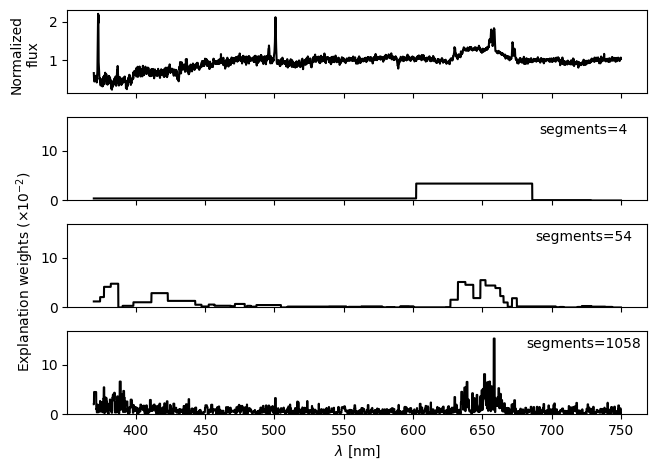

In [125]:
kmeans_lime_config = {
    "segmentation": "kmeans",
    "number_segments": 0,
    "number_samples": 5000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10000,
}

broad_near_halpha_id = 2664004586678806528
idx_spectrum = specobjid_to_idx(broad_near_halpha_id, idx_id)
spec_broad_near_halpha = spectra[idx_spectrum]


# weights_perturbations = []
# whys_perturbations = []

# n_segments = [10, 110, 942]
# n_kmeans_segments = []
# for n in n_segments:

#     kmeans_lime_config["number_segments"] = n

#     weights, why = unit_norm_weights(
#         wave, spec_broad_near_halpha,
#         base_line_score_config,
#         kmeans_lime_config,
#         baseline_fudge_config,
#         ae_model
#     )
#     n_kmeans_segments.append(np.unique(why.segments).size)
#     weights_perturbations.append(weights)
#     whys_perturbations.append(why)

# ##############################################################
# Generate perturbation figures
n_segments_labels = [f"segments={n}" for n in n_kmeans_segments]

fig, axs = plt.subplots(
    nrows=1 + len(n_kmeans_segments),
    ncols=1,
    sharex=True,
)

axs[0].plot(wave, spec_broad_near_halpha, c="black")

for idx, weights in enumerate(weights_perturbations):

    axs[idx + 1].plot(
        wave,
        weights,
        color="black",
        label=n_segments_labels[idx],
    )

# axs[-1].set_xlabel(r"$\lambda$ [$\AA$]")
axs[-1].set_xlabel(r"$\lambda$ [nm]")

for idx, n in enumerate(n_segments_labels):
    axs[idx + 1].text(
        0.89,
        0.84,
        n,
        horizontalalignment="center",
        verticalalignment="center",
        transform=axs[idx + 1].transAxes,
        # fontsize="small",
    )
max_weight = 1.1*np.nanmax(weights_perturbations)
for ax in axs[1:]:
    ax.set_ylim(0, max_weight)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{int(x * 100)}")
    )
    ax.set_ylabel("")

# Compute center of bottom three axes
bottom_y = axs[3].get_position().y0
top_y = axs[1].get_position().y1
center_y = (bottom_y + top_y) / 2

# Add vertical label
font_size = None
x_vertical = 0.0
fig.text(
    x_vertical, center_y + 0.03,
    "Explanation weights ($\\times 10^{-2}$)",
    va='center', ha='center',
    rotation='vertical', fontsize=font_size
)

bbox = axs[0].get_position()
center_y_flux = (bbox.y0 + bbox.y1) / 2

fig.text(
    x_vertical, center_y_flux + 0.08,
    "Normalized\nflux",
    va='center', ha='center',
    rotation='vertical', fontsize=font_size
)


# fig.suptitle("Explanation weights with different number of kmeans segments")

segmentation = kmeans_lime_config["segmentation"]
explanation_str = f"{segmentation}_{base_line_metric_str}"
fig_name = f"n_segments_{explanation_str}_specobjid_{broad_near_halpha_id}"
fig_name

plt.tight_layout()
fig.savefig(f"{params_dir}/{fig_name}.pdf", bbox_inches="tight")
fig.savefig(f"{params_dir}/{fig_name}.jpeg", bbox_inches="tight")

fig.savefig(f"{paper_figs_dir}/perturbation/{fig_name}.pdf", bbox_inches="tight")
fig.savefig(f"{paper_figs_dir}/perturbation/jpeg/{fig_name}.jpeg", bbox_inches="tight")


# N perturbed samples

Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations


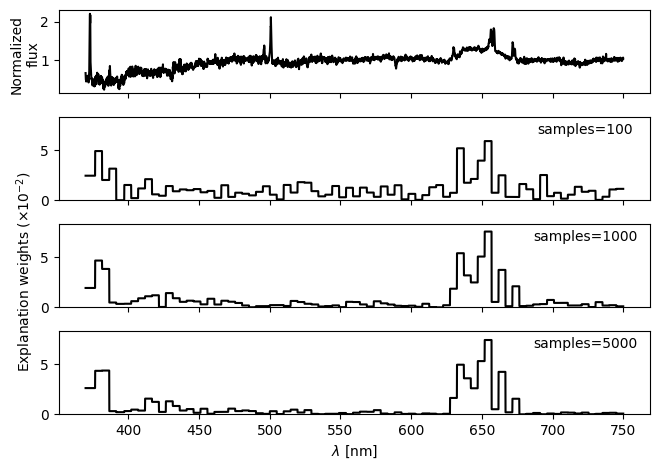

In [128]:
samples_lime_config = {
    "segmentation": "uniform",
    "number_segments": 77,
    "number_samples": None,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10000,
}

broad_near_halpha_id = 2664004586678806528
idx_spectrum = specobjid_to_idx(broad_near_halpha_id, idx_id)
spec_broad_near_halpha = spectra[idx_spectrum]


weights_perturbations = []
whys_perturbations = []

n_samples = [100, 1000, 5000]

for n in n_samples:

    samples_lime_config["number_samples"] = n

    weights, why = unit_norm_weights(
        wave, spec_broad_near_halpha,
        base_line_score_config,
        samples_lime_config,
        baseline_fudge_config,
        ae_model
    )

    weights_perturbations.append(weights)
    whys_perturbations.append(why)

# ##############################################################
# Generate perturbation figures
n_samples_labels = [f"samples={n}" for n in n_samples]

fig, axs = plt.subplots(
    nrows=1 + len(n_samples),
    ncols=1,
    sharex=True,
)

axs[0].plot(wave, spec_broad_near_halpha, c="black")


for idx, weights in enumerate(weights_perturbations):

    axs[idx + 1].plot(
        wave,
        weights,
        color="black",
        label=n_samples_labels[idx],
    )

# axs[-1].set_xlabel(r"$\lambda$ [$\AA$]")
axs[-1].set_xlabel(r"$\lambda$ [nm]")


for idx, n in enumerate(n_samples_labels):
    axs[idx + 1].text(
        0.89,
        0.84,
        n,
        horizontalalignment="center",
        verticalalignment="center",
        transform=axs[idx + 1].transAxes,
        # fontsize="small",
    )
max_weight = 1.1*np.nanmax(weights_perturbations)
for ax in axs[1:]:
    ax.set_ylim(0, max_weight)
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{int(x * 100)}")
    )
    ax.set_ylabel("")

# Compute center of bottom three axes
bottom_y = axs[3].get_position().y0
top_y = axs[1].get_position().y1
center_y = (bottom_y + top_y) / 2

# Add vertical label
font_size = None
x_vertical = 0.0
fig.text(
    x_vertical, center_y + 0.03,
    "Explanation weights ($\\times 10^{-2}$)",
    va='center', ha='center',
    rotation='vertical', fontsize=font_size
)

bbox = axs[0].get_position()
center_y_flux = (bbox.y0 + bbox.y1) / 2

fig.text(
    x_vertical, center_y_flux + 0.08,
    "Normalized\nflux",
    va='center', ha='center',
    rotation='vertical', fontsize=font_size
)

# fig.suptitle("Explanation weights with different number of samples")

segmentation = samples_lime_config["segmentation"]
explanation_str = f"{segmentation}_{base_line_metric_str}"
fig_name = f"n_samples_{explanation_str}_specobjid_{broad_near_halpha_id}"
fig_name

plt.tight_layout()
fig.savefig(f"{params_dir}/{fig_name}.pdf", bbox_inches="tight")
fig.savefig(f"{params_dir}/{fig_name}.jpeg", bbox_inches="tight")

fig.savefig(f"{paper_figs_dir}/perturbation/{fig_name}.pdf", bbox_inches="tight")
fig.savefig(f"{paper_figs_dir}/perturbation/jpeg/{fig_name}.jpeg", bbox_inches="tight")
